# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [3]:
from topological_insulator import Problem

structure_path = "../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name)

In [ ]:
import numpy as np

subs = ["A", "B"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    try:
        parser["chadi_soc"][sub_label]["lambda_pp"] = 0.3
        pass
    except:
        pass
    for nn_label in subs:
        if sub_label == nn_label:
            continue
        parser["nn_hopping"][nn_label]["t_ss_sigma"] = -np.sqrt(2)
        parser["nn_hopping"][nn_label]["t_sp_sigma"] = 1
        parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
        parser["nn_hopping"][nn_label]["t_pp_pi"] = -2

In [ ]:
location = "bulk"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


## Clebsch-Gordan Coefficients

In [ ]:
tb = problem.hamiltonian[location]["tight_binding"]
tb.sublattice_data_dict["A"].keys()
sublattice = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

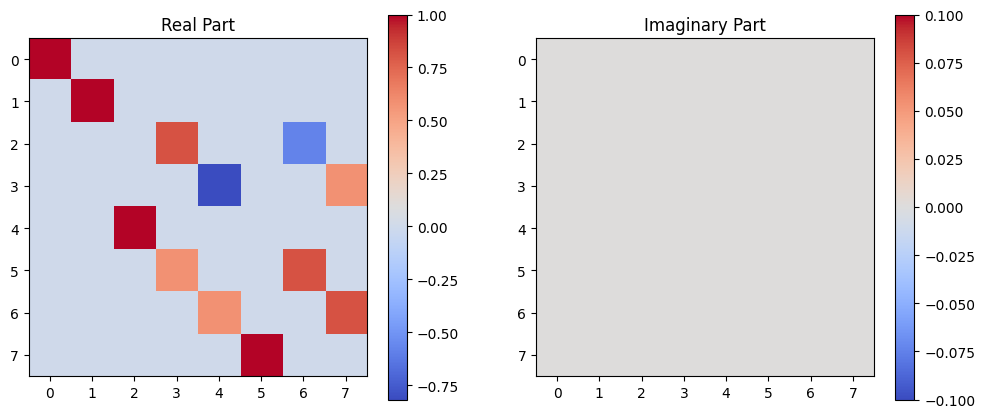

In [ ]:
tb._visualise_matrix(tb.C)

In [ ]:
uncoupled_cols = [
    (0, +0.5), (0, -0.5),
    (+1, +0.5), (+1, -0.5), 
    (-1, +0.5), (-1, -0.5), 
    (0, +0.5), (0, -0.5)
]
J_z_uncoupled = np.diag([m_l + m_s for m_l, m_s in uncoupled_cols])
J_z_coupled = tb.C @ J_z_uncoupled @ tb.C.conj().T
diag = np.diag(J_z_coupled)
print("J_z diagonal:", np.round(diag, 3))

J_z diagonal: [ 0.5 -0.5  0.5 -0.5  1.5  0.5 -0.5 -1.5]


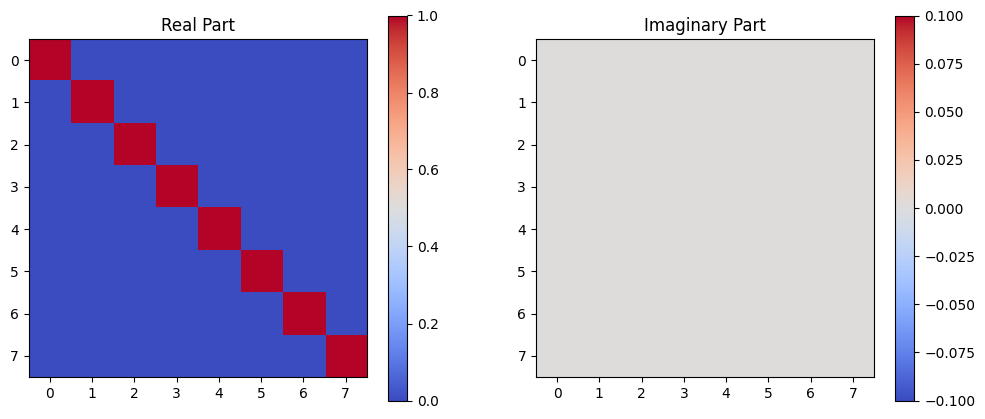

In [ ]:
tb._visualise_matrix(tb.C.conj().T @ tb.C)

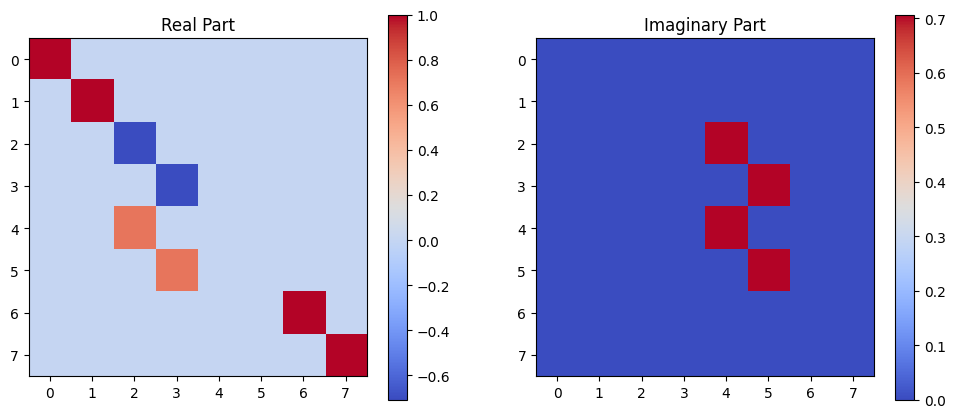

In [ ]:
tb._visualise_matrix(tb.T)

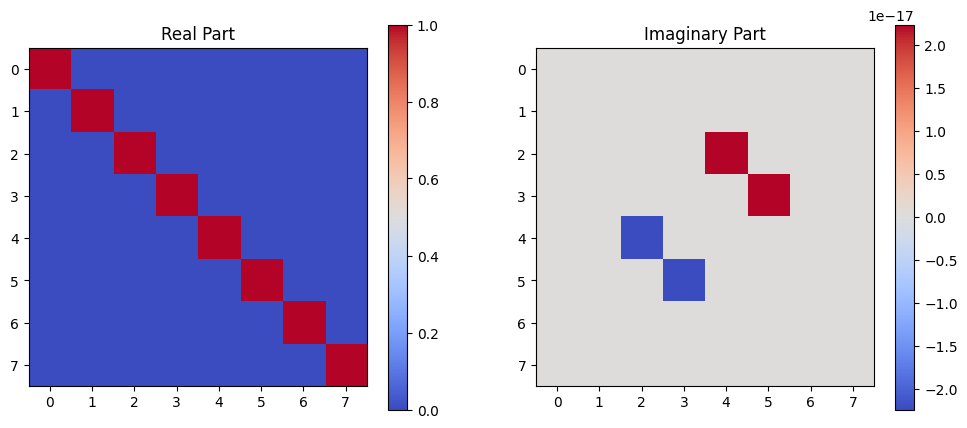

In [ ]:
tb._visualise_matrix(tb.T.conj().T@tb.T)

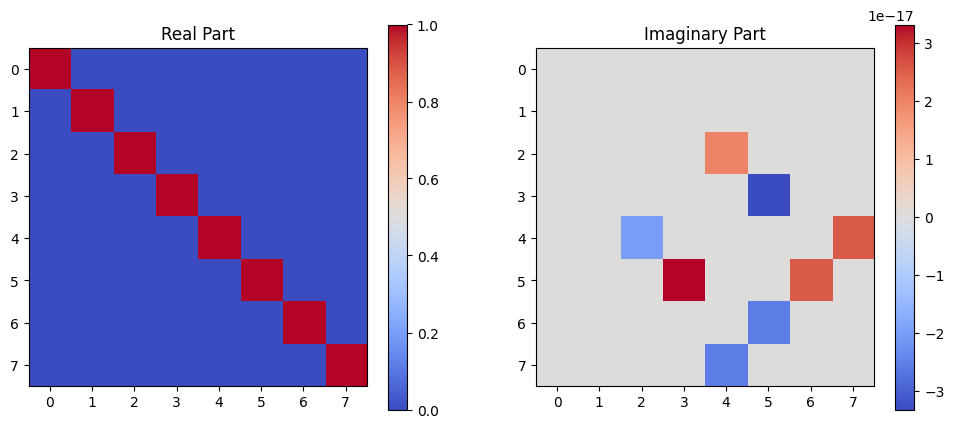

In [ ]:
P = tb.C @ tb.T
P_dagger = tb.T.conj().T @ tb.C.conj().T
tb._visualise_matrix(P_dagger @ P)

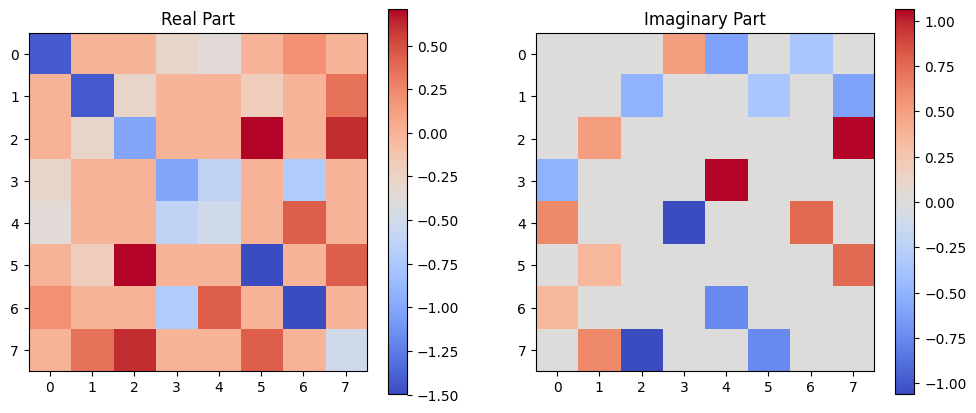

In [ ]:
idx = tb.sublattice_data_dict["A"]["NN_idxs"][0]
tb._visualise_matrix(tb.sublattice_data_dict["A"]['hopping_dict'][idx])

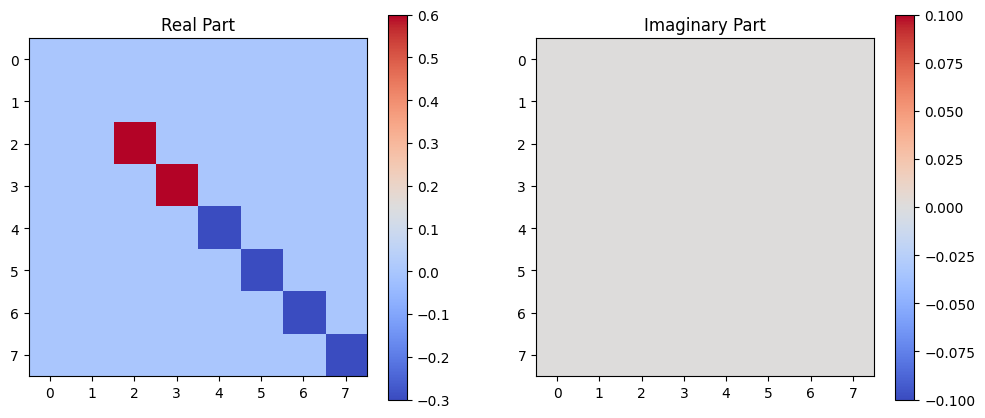

In [ ]:
idx = tb.sublattice_data_dict["A"]["idx"]
tb._visualise_matrix(tb.sublattice_data_dict["A"]['chadi_coupling_dict'][idx])